
# Inteligência de Demanda por Categoria

## Objetivo

Analisar o comportamento da demanda por categoria de produto utilizando modelos preditivos e indicadores de risco operacional.

O foco desta etapa é transformar previsões de demanda em insights estratégicos para:
- supply chain
- gestão de estoque
- reposição inteligente
- redução de ruptura
- otimização de compras

## ❓ Perguntas de Negócio

- Quais categorias possuem maior demanda?
- Quais categorias são mais previsíveis?
- Quais categorias possuem maior variabilidade?
- Quais categorias apresentam maior risco de ruptura?
- Quais categorias demandam maior atenção logística?

## 2. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor

from IPython.display import Markdown
from IPython.core.display import HTML
import math

import glob
import warnings
warnings.filterwarnings('ignore')




## 3. Configurações Iniciais

In [2]:
# Cor principal do projeto
PRIMARY_COLOR = "#50e550"
SECONDARY_COLORS = sns.light_palette(PRIMARY_COLOR, n_colors=5)

# Estilo geral
sns.set_theme(style="whitegrid")

# Tamanho padrão
plt.rcParams['figure.figsize'] = (10, 6)

# Fonte
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Carregamento dos Dados

In [3]:
df = pd.read_parquet(
    '../data/processed/df_features.parquet'
)

df.head()           


,product_id,date,sales,day_of_week,day,month,year,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
133,008cff0e5792219fae03e570f980b330,2018-07-18,2,2,18,7,2018,29,1.0,2.0,1.0,1.142857,1.142857,0.377964
134,008cff0e5792219fae03e570f980b330,2018-07-20,1,4,20,7,2018,29,2.0,1.0,1.0,1.142857,1.214286,0.377964
135,008cff0e5792219fae03e570f980b330,2018-08-01,1,2,1,8,2018,31,1.0,1.0,1.0,1.142857,1.214286,0.377964
136,008cff0e5792219fae03e570f980b330,2018-08-13,1,0,13,8,2018,33,1.0,1.0,1.0,1.142857,1.214286,0.377964
137,008cff0e5792219fae03e570f980b330,2018-08-20,1,0,20,8,2018,34,1.0,1.0,1.0,1.142857,1.214286,0.377964


In [4]:
df_analytics = pd.read_parquet(
    '../data/processed/df_analytics.parquet'
)

In [5]:
# tabela auxiliar
product_categories = (
    df_analytics[
        ['product_id', 'product_category_name']
    ]
    .drop_duplicates()
)

In [6]:
## merge df_features
df = df.merge(
    product_categories,
    on='product_id',
    how='left'
)

## 5. Verificação Inicial

In [7]:
df.head()

,product_id,date,sales,day_of_week,day,month,year,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7,product_category_name
0,008cff0e5792219fae03e570f980b330,2018-07-18,2,2,18,7,2018,29,1.0,2.0,1.0,1.142857,1.142857,0.377964,esporte_lazer
1,008cff0e5792219fae03e570f980b330,2018-07-20,1,4,20,7,2018,29,2.0,1.0,1.0,1.142857,1.214286,0.377964,esporte_lazer
2,008cff0e5792219fae03e570f980b330,2018-08-01,1,2,1,8,2018,31,1.0,1.0,1.0,1.142857,1.214286,0.377964,esporte_lazer
3,008cff0e5792219fae03e570f980b330,2018-08-13,1,0,13,8,2018,33,1.0,1.0,1.0,1.142857,1.214286,0.377964,esporte_lazer
4,008cff0e5792219fae03e570f980b330,2018-08-20,1,0,20,8,2018,34,1.0,1.0,1.0,1.142857,1.214286,0.377964,esporte_lazer


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14470 entries, 0 to 14469
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_id             14470 non-null  str           
 1   date                   14470 non-null  datetime64[ms]
 2   sales                  14470 non-null  int64         
 3   day_of_week            14470 non-null  int32         
 4   day                    14470 non-null  int32         
 5   month                  14470 non-null  int32         
 6   year                   14470 non-null  int32         
 7   week_of_year           14470 non-null  UInt32        
 8   lag_1                  14470 non-null  float64       
 9   lag_7                  14470 non-null  float64       
 10  lag_14                 14470 non-null  float64       
 11  rolling_mean_7         14470 non-null  float64       
 12  rolling_mean_14        14470 non-null  float64       
 13  rolling_std_

## 6. Categorias com maior demanda

Objetivo

Identificar:

- categorias mais relevantes
- produtos estratégicos

Análise das categorias com maior volume de vendas.

In [9]:
category_demand = (
    df.groupby('product_category_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

In [10]:
category_demand.head()

,product_category_name,sales
0,beleza_saude,2503
1,ferramentas_jardim,2295
2,cama_mesa_banho,2191
3,informatica_acessorios,2032
4,relogios_presentes,2022


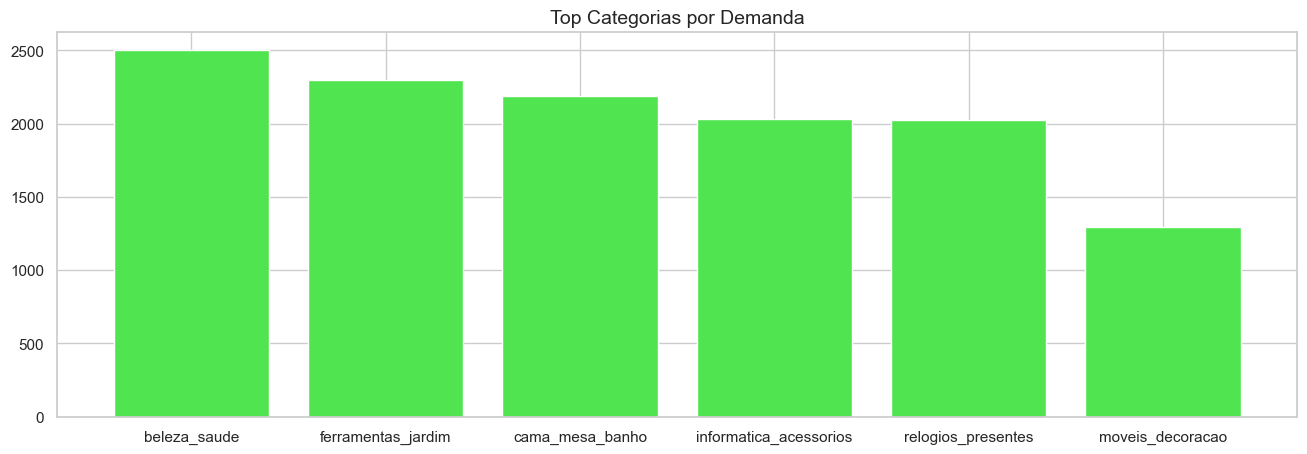

In [11]:
plt.figure(figsize=(16,5))

plt.bar(
    category_demand['product_category_name'][:6],
    category_demand['sales'][:6],
    color=PRIMARY_COLOR
)

plt.xticks(rotation=0)

plt.title('Top Categorias por Demanda')

plt.show()

## 7. Categorias Mais Instáveis

Variabilidade da Demanda

Categorias com maior desvio padrão de vendas possuem comportamento mais instável e maior dificuldade de previsão.

In [12]:
category_variability = (
    df.groupby('product_category_name')['sales']
      .std()
      .sort_values(ascending=False)
      .reset_index()
)

category_variability.columns = [
    'product_category_name',
    'sales_std'
]

category_variability.head(10)

,product_category_name,sales_std
0,ferramentas_jardim,1.826971
1,moveis_decoracao,1.587796
2,relogios_presentes,1.449152
3,informatica_acessorios,1.072453
4,moveis_escritorio,1.054029
5,bebidas,0.981611
6,utilidades_domesticas,0.966398
7,papelaria,0.952067
8,brinquedos,0.905729
9,beleza_saude,0.884222


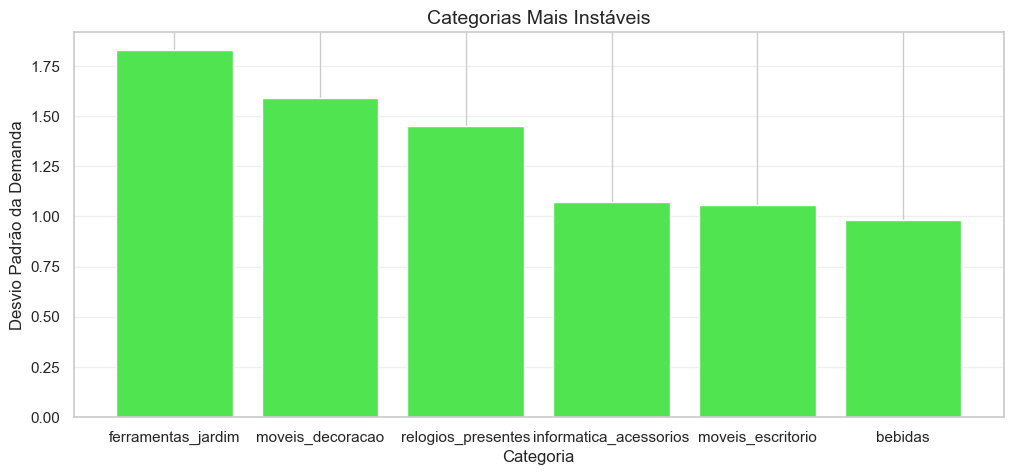

In [13]:
plt.figure(figsize=(12,5))

plt.bar(
    category_variability['product_category_name'][:6],
    category_variability['sales_std'][:6],
    color=PRIMARY_COLOR
)

plt.title('Categorias Mais Instáveis')

plt.xlabel('Categoria')

plt.ylabel('Desvio Padrão da Demanda')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

## 8.Modelagem Preditiva por Categoria

Será utilizado o modelo XGBoost para prever demanda individualmente para as categorias mais relevantes.

In [14]:
top_categories = (
    category_demand['product_category_name']
    .head(20)
    .tolist()
)

top_categories

['beleza_saude',
 'ferramentas_jardim',
 'cama_mesa_banho',
 'informatica_acessorios',
 'relogios_presentes',
 'moveis_decoracao',
 'cool_stuff',
 'esporte_lazer',
 'perfumaria',
 'telefonia',
 'utilidades_domesticas',
 'eletronicos',
 'brinquedos',
 'automotivo',
 'bebes',
 'papelaria',
 'moveis_escritorio',
 'fashion_bolsas_e_acessorios',
 'consoles_games',
 'malas_acessorios']

In [15]:
features = [
    'day_of_week',
    'month',
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_std_7'
]

target = 'sales'

In [16]:
results = []

predictions_all = []

## 9. Treinamento e Avaliação

In [17]:
for category in top_categories:

    print(f'Categoria: {category}')

    df_cat = df[
        df['product_category_name'] == category
    ].copy()

    df_cat = df_cat.sort_values('date')

    split_date = df_cat['date'].quantile(0.80)

    train = df_cat[df_cat['date'] <= split_date]

    test = df_cat[df_cat['date'] > split_date]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    mape = mean_absolute_percentage_error(y_test,preds)

    results.append({
        'category': category,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'mape':mape
    })

    temp_df = test.copy()

    temp_df['prediction'] = preds

    predictions_all.append(temp_df)

Categoria: beleza_saude
Categoria: ferramentas_jardim
Categoria: cama_mesa_banho
Categoria: informatica_acessorios
Categoria: relogios_presentes
Categoria: moveis_decoracao
Categoria: cool_stuff
Categoria: esporte_lazer
Categoria: perfumaria
Categoria: telefonia
Categoria: utilidades_domesticas
Categoria: eletronicos
Categoria: brinquedos
Categoria: automotivo
Categoria: bebes
Categoria: papelaria
Categoria: moveis_escritorio
Categoria: fashion_bolsas_e_acessorios
Categoria: consoles_games
Categoria: malas_acessorios


## 10. Resultados dos Modelos por Categorias

In [18]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values('MAE')

results_df

,category,MAE,RMSE,R2,mape
13,automotivo,0.188280,0.382096,-0.122519,0.129531
18,consoles_games,0.283961,0.390952,-0.748603,0.243553
11,eletronicos,0.296686,0.544475,-0.230465,0.219953
7,esporte_lazer,0.378046,0.519277,-0.196457,0.295110
17,fashion_bolsas_e_acessorios,0.380051,0.708479,-0.214781,0.199852
14,bebes,0.394471,0.535958,-1.555998,0.340402
12,brinquedos,0.403832,0.592887,-1.330000,0.341355
6,cool_stuff,0.420694,0.575508,-0.796263,0.355302
19,malas_acessorios,0.436689,0.595438,-0.478533,0.342694
2,cama_mesa_banho,0.444985,0.686181,-0.407009,0.333680


##  11. Categorias Mais Previsíveis

Categorias com menor MAE possuem comportamento mais estável e previsível.

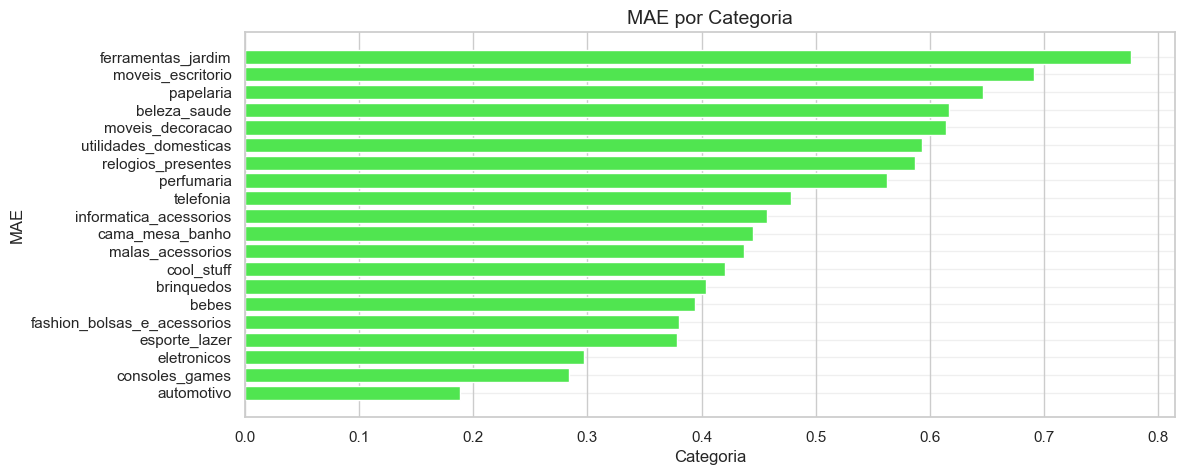

In [19]:
plt.figure(figsize=(12,5))

plt.barh(
    results_df['category'],
    results_df['MAE'],
    color=PRIMARY_COLOR
)

plt.title('MAE por Categoria')

plt.xlabel('Categoria')

plt.ylabel('MAE')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

## 12. Simulação de Estoque

Como o dataset não possui informações reais de estoque, será criada uma simulação baseada na média móvel de vendas.

In [20]:
predictions_df = pd.concat(
    predictions_all
)

In [21]:
predictions_df['simulated_stock'] = (
    predictions_df['rolling_mean_7']
    +
    predictions_df['rolling_std_7']
)

## 13. Cálcular do Risco de Ruptura (%)

O risco de ruptura representa quanto a demanda prevista excede o estoque disponível.

Fórmula:

Risco (%) = (Previsão - Estoque) / Estoque

In [22]:
predictions_df['rupture_risk_pct'] = (
    (
        predictions_df['prediction']
        -
        predictions_df['simulated_stock']
    )
    /
    predictions_df['simulated_stock']
)

In [23]:
predictions_df['rupture_risk_pct'] = (
    predictions_df['rupture_risk_pct']
    .clip(lower=0)
)

In [24]:
predictions_df['rupture_risk_pct'] *= 100

## 14. Categorias com Maior Risco de Ruptura

In [25]:
rupture_by_category = (
    predictions_df.groupby(
        'product_category_name'
    )['rupture_risk_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

rupture_by_category.head(10)

,product_category_name,rupture_risk_pct
0,papelaria,24.001233
1,moveis_escritorio,22.797266
2,bebes,13.846461
3,malas_acessorios,11.769701
4,cool_stuff,10.488044
5,beleza_saude,9.021755
6,brinquedos,7.872945
7,perfumaria,7.855873
8,relogios_presentes,7.744090
9,cama_mesa_banho,7.516199


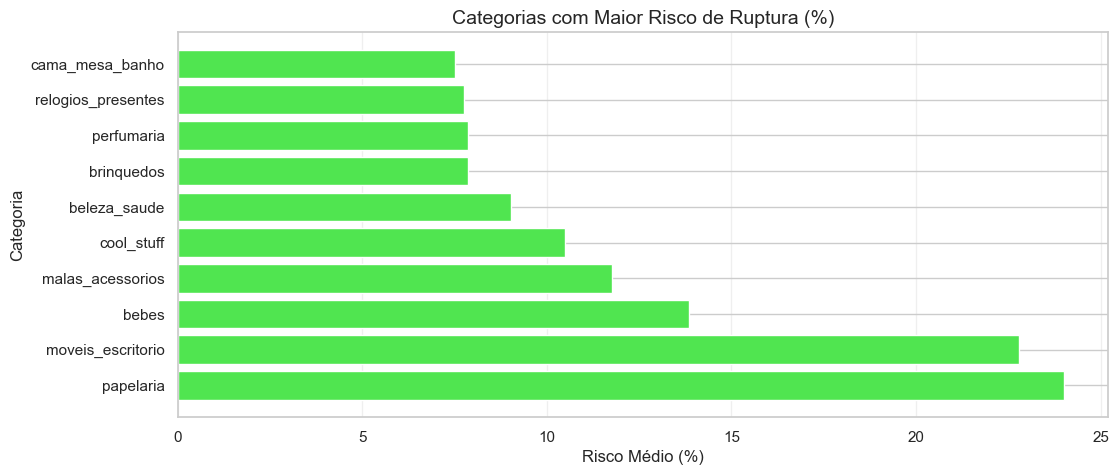

In [26]:
plt.figure(figsize=(12,5))

plt.barh(
    rupture_by_category[
        'product_category_name'
    ][:10],

    rupture_by_category[
        'rupture_risk_pct'
    ][:10],

    color=PRIMARY_COLOR
)

plt.title(
    'Categorias com Maior Risco de Ruptura (%)'
)

plt.xlabel('Risco Médio (%)')

plt.ylabel('Categoria')

plt.grid(axis='x', alpha=0.3)

plt.show()

## 15. Cálcular do Overstock (excesso de estoque) 

- excesso de estoque (overstock)

Excesso de estoque gera:

- capital parado
- custo de armazenagem
- desperdício
- risco de obsolescência

Overstock = (Estoque - Previsão) / Estoque

In [27]:
predictions_df['overstock_pct'] = (
    (
        predictions_df['simulated_stock']
        -
        predictions_df['prediction']
    )
    /
    predictions_df['simulated_stock']
)

predictions_df['overstock_pct'] = (
    predictions_df['overstock_pct']
    .clip(lower=0)
)

predictions_df['overstock_pct'] *= 100

## 16. Categorias com Maior Overstock

In [28]:
overstock_by_category = (
    predictions_df.groupby(
        'product_category_name'
    )['overstock_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

overstock_by_category.head(10)

,product_category_name,overstock_pct
0,fashion_bolsas_e_acessorios,30.385442
1,telefonia,27.556081
2,beleza_saude,27.410132
3,informatica_acessorios,27.392166
4,ferramentas_jardim,26.864787
5,utilidades_domesticas,26.622466
6,brinquedos,25.010073
7,perfumaria,24.012529
8,moveis_decoracao,23.693614
9,consoles_games,23.412167


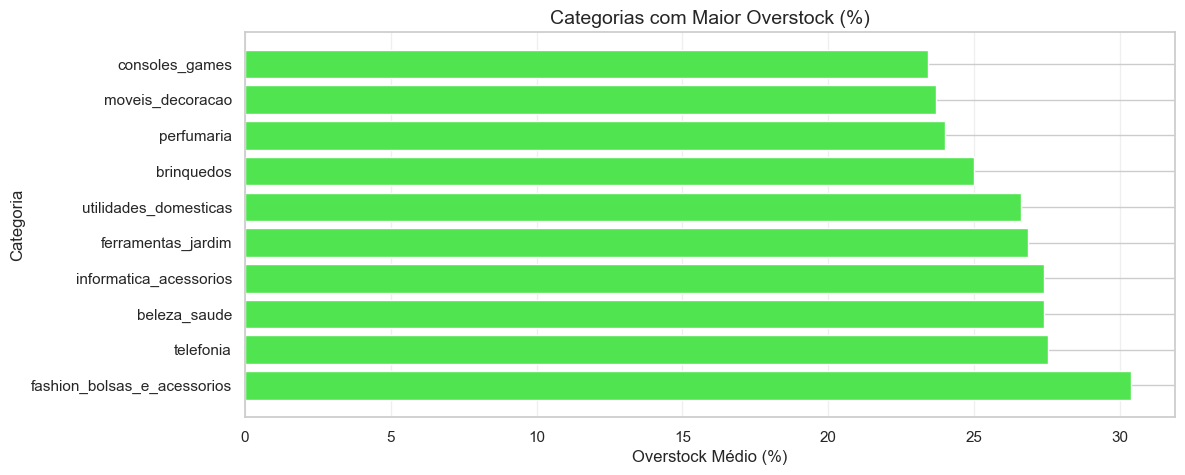

In [29]:
plt.figure(figsize=(12,5))

plt.barh(
    overstock_by_category[
        'product_category_name'
    ][:10],

    overstock_by_category[
        'overstock_pct'
    ][:10],

    color=PRIMARY_COLOR
)

plt.title(
    'Categorias com Maior Overstock (%)'
)

plt.xlabel('Overstock Médio (%)')

plt.ylabel('Categoria')

plt.grid(axis='x', alpha=0.3)

plt.show()

Categorias com alto overstock apresentam estoque acima da demanda prevista, indicando possível excesso de armazenagem e capital parado.

Essas categorias podem demandar:
- revisão da política de compras
- redução de estoque de segurança
- ações promocionais
- otimização logística

## 17. Evolução da Demanda no Tempo

In [30]:
category_example = top_categories[0]

plot_df = predictions_df[
    predictions_df['product_category_name']
    == category_example
].copy()

plot_df = plot_df.sort_values('date')

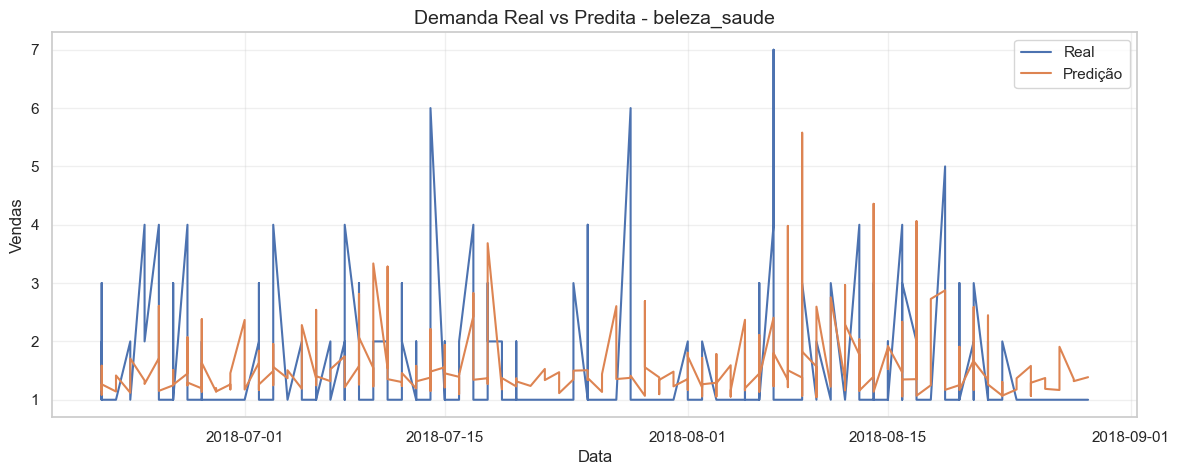

In [31]:
plt.figure(figsize=(14,5))

plt.plot(
    plot_df['date'],
    plot_df['sales'],
    label='Real'
)

plt.plot(
    plot_df['date'],
    plot_df['prediction'],
    label='Predição'
)

plt.title(
    f'Demanda Real vs Predita - {category_example}'
)

plt.xlabel('Data')

plt.ylabel('Vendas')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

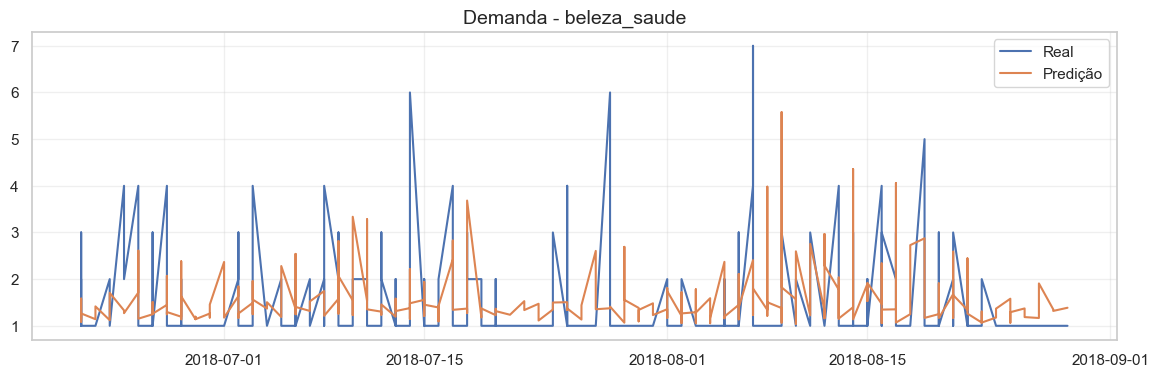

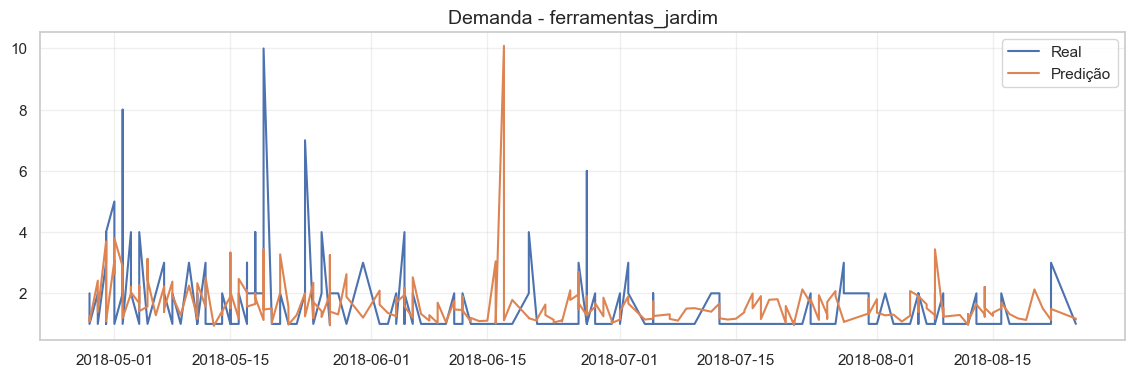

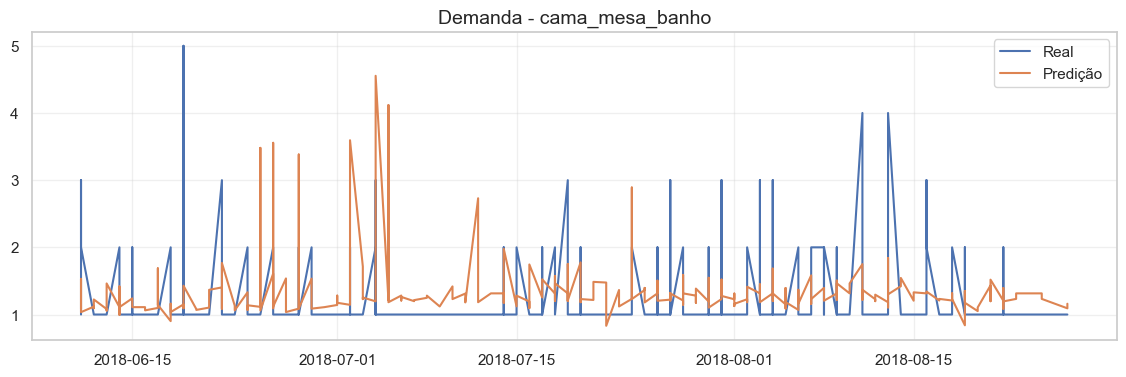

In [32]:
for category in top_categories[:3]:

    plot_df = predictions_df[
        predictions_df['product_category_name']
        == category
    ].copy()

    plot_df = plot_df.sort_values('date')

    plt.figure(figsize=(14,4))

    plt.plot(
        plot_df['date'],
        plot_df['sales'],
        label='Real'
    )

    plt.plot(
        plot_df['date'],
        plot_df['prediction'],
        label='Predição'
    )

    plt.title(
        f'Demanda - {category}'
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

## 18. Feature Importance

In [33]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df

,Feature,Importance
2,lag_1,0.254529
5,rolling_mean_7,0.153899
4,lag_14,0.141662
0,day_of_week,0.106287
1,month,0.098485
6,rolling_mean_14,0.091150
7,rolling_std_7,0.085311
3,lag_7,0.068677


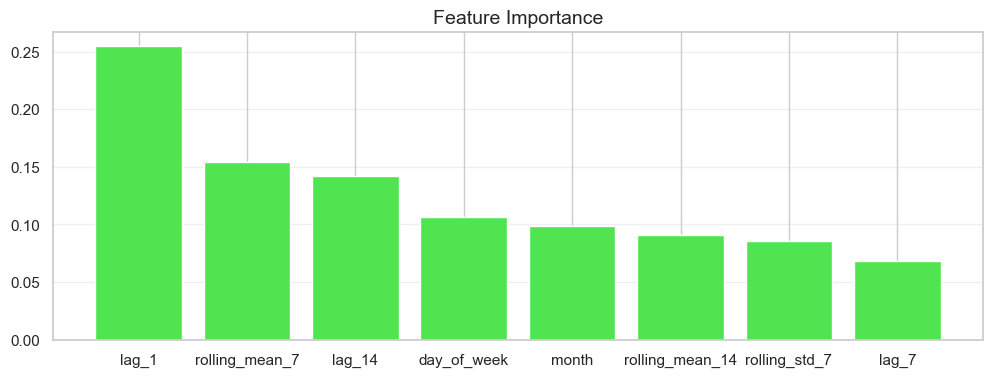

In [34]:
plt.figure(figsize=(12,4))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance'],
    color=PRIMARY_COLOR
)

plt.title('Feature Importance')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

## 19. Salvando Resultados

In [35]:
results_df.to_parquet(
    '../data/processed/category_forecast_metrics.parquet'
)

In [36]:
predictions_df.to_parquet(
    '../data/processed/category_forecast.parquet'
)

In [37]:
importance_df.to_parquet(
    '../data/processed/feature_importance.parquet'
)

## 💡 Insights Estratégicos

A análise por categoria permitiu identificar diferenças importantes no comportamento da demanda.

Principais observações:
- categorias mais previsíveis possuem menor risco operacional
- categorias instáveis apresentam maior dificuldade de planejamento
- categorias com maior risco de ruptura exigem maior estoque de segurança
- categorias de alta demanda possuem maior impacto financeiro e logístico

Esses insights podem apoiar:
- reposição inteligente
- planejamento de compras
- definição de estoque de segurança
- redução de ruptura
- otimização da cadeia de suprimentos

## 20. Conclusão

A modelagem por categoria transformou previsões de demanda em inteligência operacional aplicada ao supply chain.

Os resultados obtidos fornecem suporte para:
- cálculo de estoque ideal
- identificação de risco de ruptura
- apoio à decisão de compra
- priorização logística
- otimização de custos operacionais
- revisão da política de compras
- redução de estoque de segurança
- ações promocionais
- otimização logística

### Próximos Passos

- estoque ideal
- ponto de reposição
- estoque de segurança
- recomendação de compra